# Advance KNN

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, accuracy_score
from sklearn.model_selection import train_test_split

### KNN Regressor

In [2]:
df = pd.read_csv('../../datasets/tips.csv', usecols=['total_bill', 'time', 'size'])
df.head()

,total_bill,time,size
0,16.99,Dinner,2
1,10.34,Dinner,3
2,21.01,Dinner,3
3,23.68,Dinner,2
4,24.59,Dinner,4


In [3]:
df['time'] = LabelEncoder().fit_transform(df['time'])

In [4]:
x = df[['time', 'size']]
y = df['total_bill']

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [6]:
# Linear Regression
lr = LinearRegression()
lr.fit(x_train, y_train)
r2_score(y_test, lr.predict(x_test))

0.4078314677485978

In [7]:
# Polynomial Regression
plr = PolynomialFeatures(degree=1)
x_train_plr = plr.fit_transform(x_train)
x_test_plr = plr.transform(x_test)

poly_lr = LinearRegression()
poly_lr.fit(x_train_plr, y_train)
r2_score(y_test, poly_lr.predict(x_test_plr))

0.40783146774859746

In [8]:
# KNN Regressor
knn_reg = KNeighborsRegressor(n_neighbors=10)
knn_reg.fit(x_train, y_train)
r2_score(y_test, knn_reg.predict(x_test))

0.34965739174232247

## Hyperparameters

In [16]:
df = pd.read_csv('../../datasets/data.csv')
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)

x_train, x_test, y_train, y_test = train_test_split(df.iloc[:,1:], df.iloc[:, 0], test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)

accuracy_score(y_test, y_pred)

0.9473684210526315

### Uniform - Weighted KNN

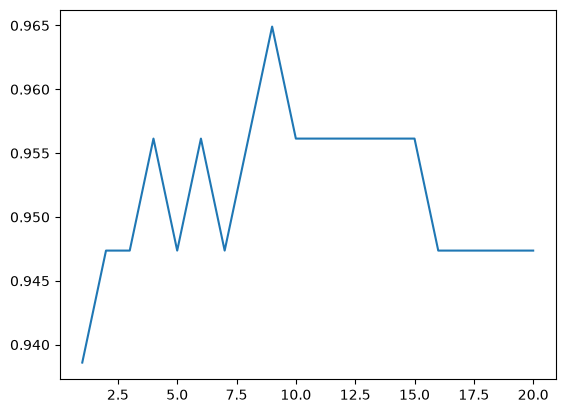

In [17]:
# knn on majority counts
acc_score = []

for i in range(1, 21):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)

    y_pred = knn.predict(x_test)

    acc_score.append(accuracy_score(y_test, y_pred))

plt.plot(range(1, 21), acc_score)
plt.show()

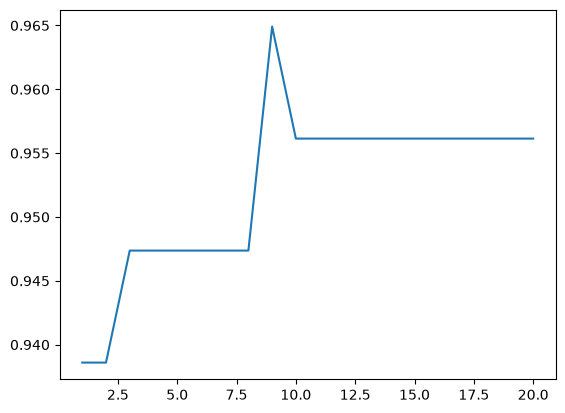

In [18]:
# KNN on weights
acc_score = []

for i in range(1, 21):
    
    knn = KNeighborsClassifier(n_neighbors=i, weights='distance')
    knn.fit(x_train, y_train)

    y_pred = knn.predict(x_test)

    acc_score.append(accuracy_score(y_test, y_pred))

plt.plot(range(1, 21), acc_score)
plt.show()

### Norms

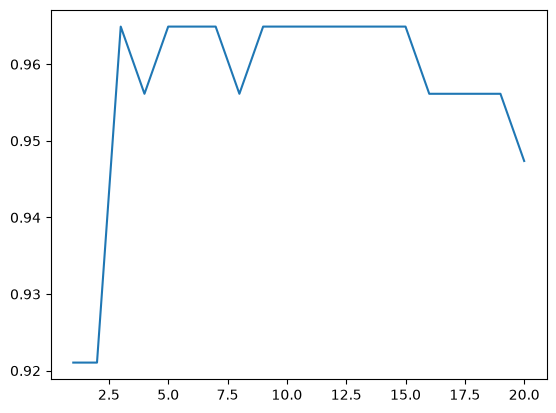

In [28]:
# Manhatten

acc_score = []

for i in range(1, 21):
    
    knn = KNeighborsClassifier(n_neighbors=i, p=1, weights='distance',n_jobs=-1) # uses multicores
    knn.fit(x_train, y_train)

    y_pred = knn.predict(x_test)

    acc_score.append(accuracy_score(y_test, y_pred))

plt.plot(range(1, 21), acc_score)
plt.show()

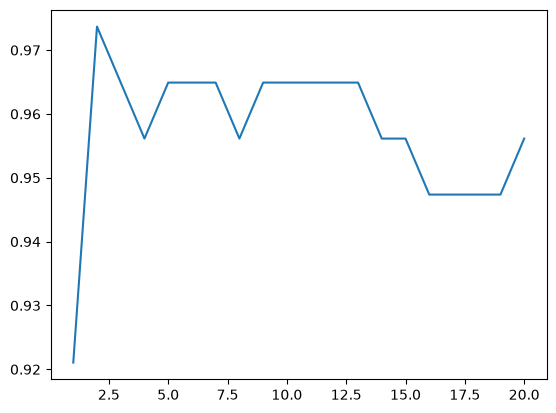

In [22]:
acc_score = []

for i in range(1, 21):
    
    knn = KNeighborsClassifier(n_neighbors=i, p=1, weights='uniform')
    knn.fit(x_train, y_train)

    y_pred = knn.predict(x_test)

    acc_score.append(accuracy_score(y_test, y_pred))

plt.plot(range(1, 21), acc_score)
plt.show()

### Algorithm

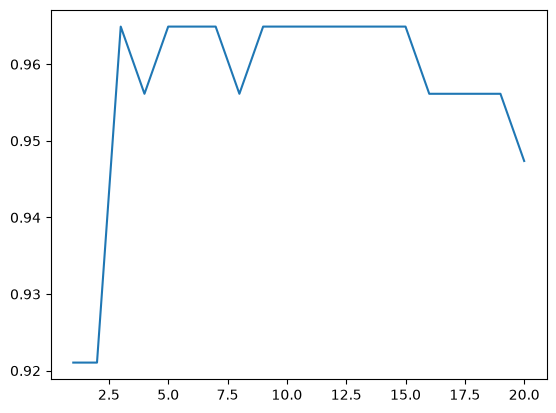

In [34]:
# Manhatten
acc_score = []

for i in range(1, 21):
    
    knn = KNeighborsClassifier(n_neighbors=i, p=1, weights='distance',n_jobs=-1, algorithm='ball_tree') # kd_tree, auto, brute
    knn.fit(x_train, y_train)

    y_pred = knn.predict(x_test)

    acc_score.append(accuracy_score(y_test, y_pred))

plt.plot(range(1, 21), acc_score)
plt.show()

### Model k=6, weights='distance', L1 norm

In [35]:
knn = KNeighborsClassifier(n_neighbors=6, weights='distance', p=1)
knn.fit(x_train, y_train)
accuracy_score(y_test, knn.predict(x_test))

0.9649122807017544